In [107]:
from typing import TypedDict, List
from langgraph.graph import StateGraph, START, END
from langchain_groq import ChatGroq
from dotenv import load_dotenv
from pydantic import BaseModel, Field
from tavily import TavilyClient
from langchain_core.messages import HumanMessage, SystemMessage
from exa_py import Exa
import os
from IPython.display import Image, display
from db.database import SessionLocal, init_db
from db.crud import create_track, save_syllabus
import re
load_dotenv()
init_db()


In [108]:
llm=ChatGroq(model_name="llama-3.3-70b-versatile", api_key=os.getenv('GROQ_API'))


In [109]:
llm.invoke("what is your name").content

'I\'m an artificial intelligence model known as Llama. Llama stands for "Large Language Model Meta AI."'

In [21]:
tavily_client = TavilyClient(api_key=os.getenv('TAVILY_API_KEY'))
response = tavily_client.search("tell me about mutual funds", include_answer=True)
response['answer']


'A mutual fund pools money from many investors to buy securities like stocks and bonds. It allows individuals to invest collectively and diversify their portfolios. Mutual funds are managed by professionals to maximize returns.'

In [4]:
exa = Exa(api_key=os.getenv("EXA_API_KEY"))

result = exa.search(
  "blog post about artificial intelligence",
  type="auto",
  contents={
    "highlights": {
      "max_characters": 4000
    }
  }
)

In [23]:
print(result)

Title: Artificial Intelligence Blog: AI Blog
URL: https://www.artificial-intelligence.blog/
ID: https://www.artificial-intelligence.blog/
Score: None
Published Date: None
Author: None
Image: http://static1.squarespace.com/static/62ec2bc76a27db7b37a2b32f/t/68974039b71d0f1a6f3e6920/1754742841664/of+ai-blog-youtube-2025.png?format=1500w
Favicon: https://images.squarespace-cdn.com/content/v1/62ec2bc76a27db7b37a2b32f/abfb4587-35b3-411f-8603-7e24344b95fc/favicon.ico?format=100w
Extras: None
Subpages: None
Text: None
Summary: None
Highlights: [' this website as a form of digital art, as all images and text were generated by artificial intelligence(with a little bit of human help). ## AI Blog Posts & AI News\n\n3 Actionable AI Recommendations for Businesses in 2026 education, business, technology In 2026, AI advantage will not come from tools but from focus. This piece outlines three concrete, disruptive moves businesses can make to turn AI into durable leverage, plus the contrarian and pessim

In [110]:
class SyllabusItem(BaseModel):
    day: int = Field(description="Day number in the syllabus")
    title: str = Field(description="Title for the day")
    description: str = Field(                               # ← NEW
        description=(
            "2–3 sentence teaser shown to the reader before they open the day's newsletter. "
            "Written in second-person ('You'll discover…', 'By the end of today…'). "
            "Specific and curious — not generic like 'We cover the basics.'"
        )
    )
    concepts: List[str] = Field(
        description="2 to 4 concepts introduced on this day"
    )
class AgentState(TypedDict):
    topic: str
    total_days: int
    syllabus: list[SyllabusItem]  # [{day, title, goal, concepts}]
    track_id: int

class SyllabusOutput(BaseModel):
    syllabus: List[SyllabusItem]
    
class DaysDecision(BaseModel):
    total_days: int = Field(ge=3, le=14, description="Number of days needed to cover this topic well for a beginner")


In [111]:

def parse_input(state: AgentState) -> dict:
    """
    Sanitise topic, then let the LLM decide the optimal number of days
    based on the topic's breadth and complexity.
    Falls back to user-provided total_days if LLM call fails.
    """
    cleaned_topic = state['topic'].strip()
    
    llm=ChatGroq(model_name="Llama-3.3-70B-Versatile", api_key=os.getenv('GROQ_API'))
    structured_llm = llm.with_structured_output(DaysDecision)

    try:
        decision: DaysDecision = structured_llm.invoke([
            SystemMessage(content="""You are a curriculum planner for a beginner learning newsletter.
Your job is to decide how many days a topic needs to be covered well — 
not too shallow, not overwhelming.

Guidelines:
- 3 days:  very focused, narrow topic (e.g. "what is a token", "how GPS works")
- 5 days:  clear single-domain topic (e.g. "how transformers work", "what is inflation")
- 7 days:  broader topic with multiple interconnected ideas (e.g. "how the internet works", "what is machine learning")
- 10 days: wide domain needing real depth (e.g. "the history of AI", "how financial markets work")
- 14 days: only for very broad domains a beginner needs significant time to absorb (e.g. "quantum computing", "evolutionary biology")

Always prefer fewer days. A tight 5-day arc beats a padded 10-day one."""),
            HumanMessage(content=f"""
Topic: "{cleaned_topic}"

How many days does this topic need for a complete beginner to genuinely understand it?
Stay between 3 and 14 days.
""")
        ])

        total_days = decision.total_days
        print(f"[parse_input] topic='{cleaned_topic}' → {total_days} days")

    except Exception as e:
        # Fall back to user-provided value, clamped to safe range
        total_days = max(3, min(14, state.get('total_days', 5)))
        print(f"[parse_input] LLM decision failed ({e}) — using {total_days} days")

    return {
        "topic":      cleaned_topic,
        "total_days": total_days,
    }

In [112]:
def generate_syllabus(state: AgentState) -> dict:
    structured_llm = llm.with_structured_output(SyllabusOutput)
    response: SyllabusOutput = structured_llm.invoke([
        SystemMessage(content="""You are an expert curriculum designer 
        specialising in beginner-friendly conceptual learning paths.
        You MUST return the response using the provided tool schema.
        The output must contain a field called `syllabus`.
        
        Your curriculum is purely theoretical — no setup, no coding, no tools.
        Every concept should be something the reader understands deeply,
        not something they do or install."""),
        HumanMessage(content=f"""
Design a {state['total_days']}-day conceptual learning curriculum for: "{state['topic']}"
Target level: complete beginner — no prior knowledge assumed

Rules:
1. Day 1 must explain what {state['topic']} is, where it came from, and why it matters
2. Each day must introduce exactly 3–4 concepts
3. Concepts must be ideas, mental models, or principles — never tasks or actions
4. Concepts must build logically from previous days
5. Day {state['total_days']} must synthesise everything — how the concepts connect and what the bigger picture looks like
6. Titles should spark curiosity, not sound like a course syllabus
7. Never include: installation, setup, coding, tools, frameworks, or hands-on tasks
8. For each day write a description: 2–3 sentences in second-person ("You'll discover…",  ← NEW
   "By the end of today…") that tease what the reader will learn. Be specific —
   never write "We cover the basics." or "An introduction to X."
""")
    ])

    print(f"[generate_syllabus] Generated {len(response.syllabus)} days")
    return {"syllabus": [s.model_dump() for s in response.syllabus]}

In [113]:
def save_to_db(state: AgentState) -> dict:
    """
    Creates a Track row and saves all SyllabusItems to SQLite.
    Returns track_id so downstream systems (Graph 2) can reference it.
    """
    db = SessionLocal()
    try:
        # Create the track
        track = create_track(
            db=db,
            topic=state["topic"],
            total_days=state["total_days"],
        )

        # Save every syllabus item
        save_syllabus(
            db=db,
            track_id=track.id,
            syllabus=state["syllabus"],   # already list[dict] from model_dump()
        )

        print(f"[save_to_db] Track {track.id} saved — {len(state['syllabus'])} days")
        return {"track_id": track.id}

    except Exception as e:
        db.rollback()
        print(f"[save_to_db] Failed: {e}")
        raise
    finally:
        db.close()

In [114]:
def build_curriculum_graph():
    g = StateGraph(AgentState)

    # nodes
    g.add_node("parse_input",       parse_input)
    g.add_node("generate_syllabus", generate_syllabus)
    g.add_node("save_to_db", save_to_db)

    # edges (connections)
    g.add_edge(START, "parse_input")
    g.add_edge("parse_input", "generate_syllabus")
    g.add_edge("generate_syllabus","save_to_db")
    g.add_edge("save_to_db",END)

    # Optionally, return or use the graph
    return g.compile()


In [33]:
curriculum_graph = build_curriculum_graph()

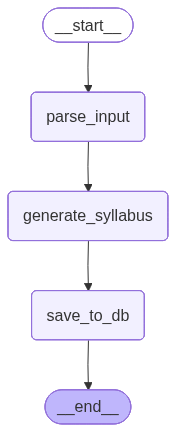

In [34]:
display(Image(curriculum_graph.get_graph().draw_mermaid_png(max_retries=5, retry_delay=2.0)))

In [35]:
test_state = {
    "topic": "Machine Learning",
    "syllabus": []}

result = curriculum_graph.invoke(test_state)
print(result)

[parse_input] topic='Machine Learning' → 7 days (Machine learning is a broader topic with multiple interconnected ideas, such as supervised and unsupervised learning, neural networks, and deep learning, which can be covered in 7 days.)
[generate_syllabus] Generated 7 days
[save_to_db] Track 2 saved — 7 days
{'topic': 'Machine Learning', 'total_days': 7, 'syllabus': [{'day': 1, 'title': 'The Secret to Machines That Learn', 'description': "You'll discover what Machine Learning is, where it came from, and why it's transforming industries. By the end of today, you'll understand the core idea behind Machine Learning and its significance in today's world. You'll explore the key milestones that led to the rise of Machine Learning.", 'concepts': ['Machine Learning', 'Artificial Intelligence', 'Data-Driven Decision Making']}, {'day': 2, 'title': 'The Building Blocks of Machine Learning', 'description': "You'll learn about the fundamental components that make Machine Learning work. By the end of

In [15]:
result['total_days']

7

MAKING THE SECOND GRAPH

In [68]:
exa = Exa(api_key=os.getenv("EXA_API_KEY"))

In [229]:
result

SearchResponse(results=[Result(url='https://www.anthropic.com/news/claude-opus-4-6', id='https://www.anthropic.com/news/claude-opus-4-6', title='Introducing Claude Opus 4.6', score=None, published_date=None, author=None, image='https://cdn.sanity.io/images/4zrzovbb/website/01d06528567e4bd22c3ddedc87f609ee5716a009-2400x1260.png', favicon='https://www.anthropic.com/favicon.ico', subpages=None, extras=None, entities=None, text=None, summary=None, highlights=[" It plans more carefully, sustains agentic tasks for longer, can operate more reliably in larger codebases, and has better code review and debugging skills to catch its own mistakes. And, in a first for our Opus-class models, Opus 4.6 features a 1M token context window in beta1. Opus 4.6 can also apply its improved abilities to a range of everyday work tasks: running financial analyses, doing  ...    can multitask autonomously, Opus 4.6 can put all these skills to work on your behalf. The model’s performance is state-of-the-art on se

In [83]:
from typing import List
from pydantic import BaseModel


class SyllabusItem(BaseModel):
    day: int
    title: str
    description: str
    concepts: List[str]

class ConceptBrief(BaseModel):
    concept: str
    definition: str      # 1 sentence — what it is
    example: str         # 1 concrete real world example
    fun_fact: str        # 1 surprising or interesting fact
    best_url: str        # single best link for further reading

class ExaResult(BaseModel):
    url: str
    title: str
    snippet: str
    summary: str


class Section(BaseModel):
    concept: str
    heading: str
    key_points: List[str] = Field(description="Exactly 3 key points, no more")
    exa_queries: List[str] = Field(description="Exactly 2 search queries, no more")
    target_words: int = Field(default=500, description="Always 500")


class Plan(BaseModel):
    newsletter_title: str
    hook: str
    sections: List[Section]
    takeaway: str

class Feedback(BaseModel):
    section: str
    issue: str
    suggestion: str


class CriticOutput(BaseModel):
    feedbacks: List[Feedback]
    approved: bool
    
class ContentState(TypedDict):
    item: SyllabusItem
    day_number: int                   
    total_days: int                   
    plan: Plan | None
    research: List[ExaResult]
    research_summary: List[ConceptBrief]
    draft: str
    feedback: str
    feedbacks: List[Feedback]         
    revision_count: int                
    approved: bool
    newsletter: str

In [84]:
def planner_node(state: ContentState) -> dict:
    PLANNER_PROMPT = """
You are creating the outline for a modern tech newsletter lesson.

The writing style should feel like popular tech newsletters such as TLDR, The Neuron, or AI Brew: smart, conversational, and easy to skim.

The reader should feel like they learned something useful in under 60 seconds.

Your job is NOT to write the full article. Your job is to produce a structured PLAN that a writer will expand into the final newsletter section.

--------------------------------------------------

INPUTS

Day: {day}
Topic Title: {title}
Concepts: {concepts}

--------------------------------------------------

TASK

Create a structured plan for a newsletter lesson.

--------------------------------------------------

INSTRUCTIONS

1. NEWSLETTER TITLE

Write a catchy newsletter-style title.

The title should:
- spark curiosity
- feel modern
- avoid textbook wording

Examples:
"Neural Networks: The Brains Behind Modern AI"
"The 3 Building Blocks Powering Every AI System"

--------------------------------------------------

2. HOOK (2–3 sentences)

Write a short opening hook that grabs attention.

The hook should:
- introduce the topic quickly
- create curiosity
- explain why the reader should care

Example tone:

"Every AI system you hear about — from ChatGPT to self-driving cars — runs on the same core idea: neural networks.

But the strange part? These powerful systems are built from extremely simple mathematical units.

Today we'll break down the three building blocks that make it all work."

--------------------------------------------------

3. SECTIONS

For EACH concept create a section containing:

heading  
An engaging section title.

Avoid generic titles like:
"Introduction to..."

Examples:
"Meet the Tiny Neurons Running the Show"
"Stacking Layers to Build Intelligence"

key_points

Write 3–5 bullet ideas explaining HOW the concept works.

Rules:
- explain the mechanism
- avoid vague statements
- focus on intuition
- keep sentences short

Bad example:
"Neurons process data"

Good example:
"A neuron takes numbers as input and multiplies them by learned weights."

exa_queries

Provide up to 2 search queries that would help find:
- examples
- case studies
- explanations
NOTE - that since exa is scemantic, the queries should be best designed for learning purposes.

Queries should be specific and useful.

--------------------------------------------------

4. STYLE GUIDELINES

The final article should feel:

• clear  
• engaging  
• beginner friendly  
• easy to skim  

Use:
- short sentences
- concrete explanations
- intuitive mental models

Avoid:
- academic language
- textbook definitions
- vague bullet points

--------------------------------------------------

5. TAKEAWAY

End with one memorable sentence capturing the big idea.

Example:

"Big idea: neural networks turn simple math operations into powerful pattern-recognition machines."

--------------------------------------------------

OUTPUT REQUIREMENTS

Return a valid Plan object with EXACTLY these fields:
- newsletter_title: string
- hook: string  
- sections: array of Section objects, one per concept
- takeaway: string

Each Section object must have EXACTLY:
- concept: string (copy from the concepts list)
- heading: string
- key_points: array of exactly 3 strings
- exa_queries: array of exactly 2 strings
- target_words: integer, always 500

No markdown. No explanation. No extra fields. JSON only.
...
"""

    prompt = PLANNER_PROMPT.format(
        day=state['item']['day'],
        title=state['item']['title'],
        concepts=", ".join(state['item']['concepts']),
    )
    llm=ChatGroq(model_name="llama-3.3-70b-versatile", api_key=os.getenv('GROQ_API_KEY'))
    plan = llm.with_structured_output(Plan).invoke(prompt)

    return {"plan": plan}

In [85]:
def research_node(state: ContentState) -> dict:
    """Based on the exa queries defined in the planner node, the exa search will be triggered"""
    
    exa_queries_list = []
    for section in state['plan'].sections:
        for query in section.exa_queries:
            exa_queries_list.append(query)
    
    print(f"\n{'='*60}")
    print(f"🔍 RESEARCHER NODE")
    print(f"{'='*60}")
    print(f"📋 Total queries to run: {len(exa_queries_list)}")
    for i, q in enumerate(exa_queries_list, 1):
        print(f"   {i}. {q}")

    query_results = []
    seen_urls = set()
    for query in exa_queries_list:
        print(f"\n🔎 Searching: '{query}'")
        result = exa.search(
            query,
            type="auto",
            num_results=2,
            contents={
                "highlights": {
                    "max_characters": 4000
                },"text":True, 'summary': True
            },
            include_domains=[
            "developers.google.com",
            "coursera.org", 
            "arxiv.org",
            "datacamp.com",
            "baeldung.com",
            "wikipedia.org",
            "towardsdatascience.com"
        ]
        )
        for item in result.results:
            if item.url in seen_urls:
                continue

            seen_urls.add(item.url)
            exa_result = ExaResult(
                url=item.url,
                title=item.title,
                summary=item.summary if item.summary else "",
                snippet=item.highlights[0] if item.highlights else ""
            )
            query_results.append(exa_result)
            print(f"   ✅ {item.title}")
            print(f"      🔗 {item.url}")
            print(f"      📝 {exa_result.snippet[:100]}...")

    print(f"\n{'='*60}")
    print(f"✅ Research complete — {len(query_results)} results collected")
    print(f"{'='*60}\n")

    return {"research": query_results}

In [86]:
def summarizer_node(state: ContentState) -> dict:
    SUMMARIZER_PROMPT = """
        You are a research distiller for a beginner-friendly learning newsletter.

        You will be given raw research results for a specific concept.
        Your job is to extract only the most valuable pieces for a newsletter writer.

        Concept: {concept}

        Raw Research:
        {raw_results}

        Extract exactly:
        - definition: one crisp sentence explaining what this concept is
        - example: one concrete real world example that makes it click for a beginner
        - fun_fact: one surprising or interesting fact that will make the reader go "wow"
        - best_url: the single most beginner friendly and informative URL from the results

        Be specific. No vague generalities.
        Return a valid ConceptBrief object."""
    print(f"\n{'='*60}")
    print("📝 SUMMARIZER NODE")
    print(f"{'='*60}")

    plan = state["plan"]
    research = state["research"]

    print(f"📋 Total raw results: {len(research)}")

    llm = ChatGroq(model="llama-3.3-70b-versatile", api_key=os.getenv("GROQ_API_KEY"))

    # group results by concept using exa_queries order
    results_per_concept = len(research) // len(plan.sections)

    briefs = []
    for i, section in enumerate(plan.sections):
        start = i * results_per_concept
        end = start + results_per_concept
        concept_results = research[start:end]

        print(f"\n🔎 Distilling: '{section.concept}' ({len(concept_results)} results)")

        # format only what matters — trim aggressively
        raw_results = "\n\n".join([
            f"Title: {r.title}\nURL: {r.url}\nSummary: {r.summary[:300]}\nSnippet: {r.snippet[:150]}"
            for r in concept_results
        ])

        prompt = SUMMARIZER_PROMPT.format(
            concept=section.concept,
            raw_results=raw_results
        )

        brief = llm.with_structured_output(ConceptBrief).invoke(prompt)
        briefs.append(brief)

        print(f"   ✅ Definition: {brief.definition[:80]}...")
        print(f"   💡 Fun fact:   {brief.fun_fact[:80]}...")
        print(f"   🔗 Best URL:   {brief.best_url}")

    print(f"\n{'='*60}")
    print(f"✅ Summarization complete — {len(briefs)} concept briefs ready")
    print(f"{'='*60}\n")

    return {"research_summary": briefs}

In [87]:
def writer_node(state: ContentState) -> dict:
    
    WRITER_PROMPT = """\
You are writing one module of a daily learning newsletter — like an email a knowledgeable
friend sends you each morning to make you genuinely smarter about one thing.

Your reader is a complete beginner. Zero prior knowledge assumed. Your job is not to
impress them — it's to make the concept click.

═══════════════════════════════════════════════════════
  MODULE BRIEF
═══════════════════════════════════════════════════════
Module Number : {day_number} of {total_days}
Module Title  : {newsletter_title}
Topic Line    : {topic_label}
Hook          : {hook}
Takeaway      : {takeaway}

Sections to cover:
{sections}

Research (weave naturally — never paste raw):
{research_summaries}

═══════════════════════════════════════════════════════
  EXACT OUTPUT FORMAT
═══════════════════════════════════════════════════════

Write the newsletter in this exact structure:

1. A level-1 heading with the newsletter title.

2. A bold topic line: **Topic: [topic name]**

3. Opening hook — 3-4 sentences. Grab attention. End with a promise of what
   the reader will understand by the end of this module.

4. A horizontal rule: ---

5. For EACH section in the plan, write the following in order:

   a) A level-2 heading with the section heading.

   b) INTRO — 2-3 sentences. Frame the concept: what is it and why does it
      matter right now?

   c) WHAT — 4-5 sentences. Define it in plain English. Bold the first
      appearance of every key term. Short, direct sentences. No jargon without
      an immediate plain-English follow-up.

   d) HOW — 5-6 sentences. Explain the mechanics step by step. Answer "but why
      does it work this way?" Use one concrete analogy if it genuinely helps —
      skip it if it feels forced.

   e) Fun fact line — start with the emoji and bold label exactly as shown:
      💡 **Fun fact:** Then 2-3 sentences from research. Something surprising —
      the reader should think "huh, I did not know that."

   f) Example block — use a blockquote starting with bold label exactly as shown:
      > **For example:** Then 4-5 sentences. Real-world example from research
      with specific names, numbers, or events. Never "imagine a company that…" —
      use a real one.

   g) WHY IT MATTERS — 3-4 sentences. Connect to something the reader already
      cares about. Tell them what would break or be different if this concept
      did not exist.

   h) Dive deeper line — start with the emoji and bold label exactly as shown:
      📖 **Dive deeper:** Then the best URL from research for this section.

   i) A horizontal rule: ---

6. Task section — bold label exactly as shown:
   **Task:**
   One concrete thought experiment or real-world observation the reader can do
   TODAY. No tools, no sign-ups, no cost. 3-4 sentences — tell them exactly
   what to do and what to notice.

7. A horizontal rule: ---

8. Closing reflection in italics — 2-3 sentences. Warm, not preachy. Leave
   them feeling like they actually learned something real today.

═══════════════════════════════════════════════════════
  WRITING RULES
═══════════════════════════════════════════════════════

TONE
• Write like a knowledgeable friend, not a professor or a hype-man.
• Warm, direct, occasionally witty — never sarcastic or condescending.
• Formal enough to be taken seriously. Casual enough to keep reading.
• Use "you" and "your" throughout. Never "one should…" or "the reader will…"

STRUCTURE
• Every paragraph: 3-5 sentences. Never more, never less.
• Blank line between EVERY paragraph and every element.
• No sub-headings inside sections — INTRO / WHAT / HOW are invisible labels
  for you, not headings that appear in the output.
• Bullet points only when listing 3+ genuinely distinct items, never as a lazy
  substitute for a good sentence.

LANGUAGE
• Bold (**term**) only when introducing a key term for the first time.
• Emojis: max 2 per section — only 💡 and 📖 in their designated spots.
• Never use: "delve", "dive into", "unpack", "let's explore", "in conclusion",
  "to summarise", "it's worth noting", "fascinating", "crucial", "game-changer".
• Analogies: one per section maximum. If a 12-year-old wouldn't get it, replace it.

TASK RULES
• One thing, doable today, no setup required.
• Thought experiment OR a real-world observation.
• Tell them exactly what to do AND what to notice.
• Good example: "Next time you open a food delivery app, look at the 'platform fee'
  line on your bill. That fee is the marketplace taking a cut without owning any
  restaurants — that's the two-sided market model in action."
• Bad example: "Think about how mutual funds work in your life." (too vague)

WORD COUNT (enforced)
• Each section: minimum 350 words.
• Full newsletter: minimum 1200 words.
• After writing, check. If any section is under 350 words, expand HOW and EXAMPLE.

═══════════════════════════════════════════════════════
  REFERENCE EXAMPLE  (tone and structure benchmark)
═══════════════════════════════════════════════════════

## Why Your Money Loses Value While Sitting in a Drawer

You've probably heard someone say "a rupee today is worth more than a rupee tomorrow."
It sounds like financial folk wisdom, but it's actually just a description of how the
world works. By the end of this section, you'll know exactly why — and why it quietly
shapes every financial decision you'll ever make.

**Inflation** is the gradual rise in the price of goods and services over time. It is
not a glitch or a failure — it is a natural byproduct of a growing economy. As people
earn more, they spend more, which pushes demand up, which pushes prices up. The cycle
compounds quietly year after year.

The mechanics are straightforward. When the central bank increases the money supply —
say, to fund public infrastructure — there is suddenly more money chasing the same
number of goods. Sellers, sensing higher demand, raise prices. This is not greed; it
is basic supply and demand. In India, the RBI targets inflation between 2-6% annually,
which means the purchasing power of 100 rupees today will be roughly 50 rupees in
12-15 years. That's not a catastrophe — it's the background hum of a functioning
economy, and understanding it is the first step to not being quietly eroded by it.

💡 **Fun fact:** During Zimbabwe's hyperinflation in 2008, prices were doubling every
24 hours. The government eventually printed a 100-trillion-dollar note — which could
barely buy a loaf of bread.

> **For example:** In 2010, a litre of petrol in India cost around 47 rupees. By 2024,
the same litre costs over 100 rupees — more than double in 14 years. If your salary
doubled over that same period, you broke even. If it didn't, you are earning less in
real terms even if the number on your payslip went up. This is the invisible tax that
inflation quietly collects from everyone.

This matters because every financial product you'll ever evaluate — fixed deposits,
mutual funds, PPF, real estate — needs to be measured against inflation, not against
zero. A fixed deposit returning 6% feels safe until you realise inflation is running
at 6.5%. You're growing your balance while shrinking your purchasing power. Inflation
is the benchmark. Beat it and you're building wealth. Fall behind it and you're
slowly getting poorer — without anyone telling you.

📖 **Dive deeper:** https://www.rbi.org.in/scripts/PublicationsView.aspx?id=12765

═══════════════════════════════════════════════════════

Return ONLY the final newsletter markdown.
No preamble. No explanation. No "Here is your newsletter:". Just the markdown.
"""



    print(f"\n{'='*60}")
    print(f"✍️  WRITER NODE")
    print(f"{'='*60}")

    plan = state["plan"]
    item = SyllabusItem(**state["item"])

    sections_text = ""
    for section in plan.sections:
        sections_text += f"""
---
Heading: {section.heading}
Concept: {section.concept}
Target Word Count: {section.target_words} words
Key Points to expand on:
{chr(10).join(f'  - {point}' for point in section.key_points)}
---
"""

    research_text = ""
    for brief in state["research_summary"]:
        research_text += f"""
    ---
    Concept: {brief.concept}
    Definition: {brief.definition}
    Real World Example: {brief.example}
    Fun Fact: {brief.fun_fact}
    Best URL: {brief.best_url}
    ---
    """

    prompt = WRITER_PROMPT.format(
        day_number        = state["day_number"],
        total_days        = state["total_days"],
        newsletter_title  = plan.newsletter_title,
        topic_label       = item.title,
        hook              = plan.hook,
        takeaway          = plan.takeaway,
        sections          = sections_text,
        research_summaries= research_text,
    )
    writer_llm=ChatGroq(model_name="meta-llama/llama-4-scout-17b-16e-instruct", api_key=os.getenv('GROQ_API'))
    draft = writer_llm.invoke(prompt).content
    word_count = len(draft.split())


    print(f"   ✅ Draft written — {word_count} words")
    print(f"{'='*60}\n")

    return {"draft": draft}

In [118]:
def critic_node(state: ContentState)->ContentState:
   """this node will give feedback based on the content that has been generated for the newsletter"""
    
   CRITIC_PROMPT = """
   You are a strict and senior newsletter editor reviewing a draft for quality.

   Your job is to flag ONLY real problems — do not rewrite, just annotate.

   Draft:
   {draft}

   Review against these rules and flag any violations:

   1. REPETITION
      - Flag any phrase, sentence, or example used more than once across the newsletter
      - Flag any section that ends with the same conclusion as another section

   2. PADDING
      - Flag any sentence that does not teach the reader something specific
      - Flag vague filler phrases like:
      * "you'll gain a deeper appreciation"
      * "every AI breakthrough you've heard of"
      * "by understanding this"
      * "the complexity and beauty of"
      * "something that seems effortless to humans"
      * Any sentence that could be deleted without losing information

   3. SHALLOW EXPLANATION
      - Flag any key point that is stated but never actually explained
      - Flag any claim made without a specific example or fact to back it up

   4. HALLUCINATION RISK
      - Flag any specific number, statistic, or claim that is not grounded in the research provided
      - Do not flag general knowledge claims

   5. REDUNDANT EXAMPLES
      - Flag if the same real world example (e.g. handwritten digits, cat recognition) is used in more than one section
      - Each section MUST use a different example

   ---

   Research used to write this newsletter:
   {research_summaries}

   ---

   For each issue found output:
   - section: which section heading has the problem
   - issue: what exactly is wrong, quote the specific text
   - suggestion: exact instruction to fix it — be specific

   If the newsletter passes all checks set approved = True and annotations = [].

   Return a valid CriticOutput object.
   IMPORTANT: approved must be JSON boolean true or false — never "True", "False", or any string.
   """
   print(f"\n{'='*60}")
   print(f"🔍 CRITIC NODE")
   print(f"{'='*60}")

   revision_count = state.get("revision_count", 0)

   # auto approve after 3 cycles
   if revision_count >= 2:
      print(f"   ⚠️ Max revisions reached — auto approving")
      return {"approved": True, "feedback": []}
     
   research_text = ""
   for brief in state["research_summary"]:
        research_text += f"""
    ---
    Concept: {brief.concept}
    Definition: {brief.definition}
    Real World Example: {brief.example}
    Fun Fact: {brief.fun_fact}
    Best URL: {brief.best_url}
    ---
    """
   prompt= CRITIC_PROMPT.format(
      draft=state['draft'],
      research_summaries=research_text
   )
   result: CriticOutput = llm.with_structured_output(CriticOutput).invoke(prompt)   
   
   for annotation in result.feedbacks:                         
      print(f"   ⚠️  [{annotation.section}] {annotation.issue[:80]}...")
      print(f"   ✅ Approved: {result.approved}")
      print(f"{'='*60}\n")
   
      return {                                                    
         "feedbacks": result.feedbacks,
         "approved": result.approved,
         "revision_count": revision_count + 1,
      }
   
    

In [119]:
def should_revise(state: ContentState) -> str:
    """
    Routes to 'writer' for another pass, or 'end' when done.
    Called after critic_node.
    """
    if state["approved"]:
        return "end"
    if state["revision_count"] >= 2:
        return "end"
    return "writer"

In [120]:
def finalizer_node(state: ContentState) -> dict:
    return {"newsletter": state["draft"]}

In [121]:
from langgraph.graph import StateGraph, START, END


def build_graph():
    g = StateGraph(ContentState)

    # Add node
    g.add_node("planner_node", planner_node)
    g.add_node("research_node", research_node)
    g.add_node("writer_node",writer_node)
    g.add_node("critic_node",critic_node)
    g.add_node("finalizer_node", finalizer_node)
    # Connect start → node
    g.add_edge(START, "planner_node")
    g.add_edge("planner_node",'research_node')
    g.add_edge("research_node",'writer_node')
    g.add_edge("writer_node","critic_node")
    g.add_edge("critic_node","finalizer_node")
    g.add_conditional_edges(
    "critic_node",           # source node
    should_revise,      # function that returns the next node name
    {
        "writer": "writer_node",   # needs revision → back to writer
        "end":    "finalizer_node",        # approved (or max revisions hit) → done
    }
    )
    g.add_edge("finalizer_node",END)
    return g.compile()

In [122]:
graph = build_graph()

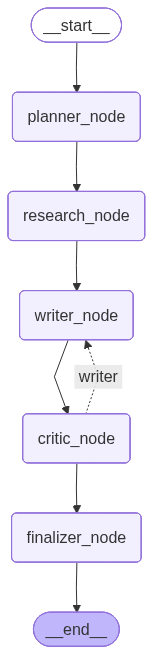

In [123]:
graph

In [ ]:
result = graph.invoke({
    "item": {
        "day": 1,
        "title": "What Is Compound Interest and Why Does It Matter?",
        "description": "You'll discover why Einstein allegedly called compound interest the eighth wonder of the world, how it silently works for or against you, and why starting early changes everything.",
        "concepts": ["compound interest", "principal", "interest rate", "time value of money"]
    },
    "day_number": 1,
    "total_days": 7,
    "plan": None,
    "research": [],
    "research_summary": [],
    "draft": "",
    "feedback": "",
    "feedbacks": [],
    "revision_count": 0,
    "approved": False,
    "newsletter": ""
})

In [ ]:
print(result['draft'])

[Feedback(section='## Demystifying Mutual Funds: Why You Should Care', issue='The concept of a mutual fund is repeated in multiple sections', suggestion='Remove repetitive explanations and focus on providing new information in each section'), Feedback(section="## What's a Mutual Fund, Anyway?", issue="The phrase 'This matters because' is used in multiple sections", suggestion='Vary sentence structure and avoid repetitive phrases'), Feedback(section='## Demystifying Mutual Funds: Why You Should Care', issue="The sentence 'Mutual funds can seem complex, but understanding the basics can help you make informed investment decisions.' does not teach the reader something specific", suggestion='Remove or replace with a sentence that provides specific information about mutual funds'), Feedback(section="## What's a Mutual Fund, Anyway?", issue='The example of the Vanguard 500 Index Fund is used to explain the concept of a mutual fund, but it is not fully explained', suggestion='Provide more deta

In [ ]:
def run_pipeline(topic: str):
    # ── Graph 1: generate syllabus ─────────────────────────
    graph1 = build_curriculum_graph()
    syllabus_result = graph1.invoke({
        "topic": topic
    })

    syllabus = syllabus_result["syllabus"]
    total_days = len(syllabus)

    print(f"\n✅ Syllabus generated — {total_days} days")

    # ── Graph 2: run once per syllabus item ────────────────
    graph2 = build_graph()
    newsletters = []

    for item in syllabus:
        print(f"\n📰 Generating Day {item['day']} — {item['title']}")
        result = graph2.invoke({
            "item": item,
            "day_number": item["day"],
            "total_days": total_days,
            "plan": None,
            "research": [],
            "research_summary": [],
            "draft": "",
            "feedback": "",
            "feedbacks": [],
            "revision_count": 0,
            "approved": False,
            "newsletter": "",
        })
        newsletters.append({
            "day": item["day"],
            "title": item["title"],
            "newsletter": result["newsletter"],
        })

    return newsletters

In [ ]:
import json
import os
from datetime import datetime

# ─────────────────────────────────────────────
# USER PROGRESS STORE  (simple JSON file)
# ─────────────────────────────────────────────

USERS_FILE = "users.json"

def load_users() -> dict:
    if not os.path.exists(USERS_FILE):
        return {}
    with open(USERS_FILE, "r") as f:
        return json.load(f)

def save_users(users: dict):
    with open(USERS_FILE, "w") as f:
        json.dump(users, f, indent=2)


# ─────────────────────────────────────────────
# USER FLOW
# ─────────────────────────────────────────────

def onboard_user(user_id: str, topic: str):
    """
    Called once when a user signs up.
    Generates the syllabus and stores day 1 content.
    """
    users = load_users()

    # generate syllabus only once
    graph1 = build_curriculum_graph()
    syllabus_result = graph1.invoke({
        "topic": topic,
        "total_days": 7,
        "syllabus": [],
        "revision_count": 0,
        "quality_score": 0.0,
        "track_id": 1,
    })
    syllabus = syllabus_result["syllabus"]

    # store user state
    users[user_id] = {
        "topic": topic,
        "syllabus": syllabus,
        "current_day": 1,
        "total_days": len(syllabus),
        "last_seen": datetime.now().isoformat(),
        "newsletters": {}           # day → newsletter content
    }
    save_users(users)

    # generate day 1 immediately
    return deliver_day(user_id)


def deliver_day(user_id: str) -> dict:
    """
    Called each time the user comes back.
    Generates today's newsletter and advances the day counter.
    """
    users = load_users()
    user = users[user_id]

    current_day = user["current_day"]
    total_days  = user["total_days"]
    syllabus    = user["syllabus"]

    # already completed the course
    if current_day > total_days:
        return {"status": "completed", "message": "You've completed the full course!"}

    # already generated today — just return it
    if str(current_day) in user["newsletters"]:
        return {
            "status": "already_generated",
            "day": current_day,
            "newsletter": user["newsletters"][str(current_day)]
        }

    # generate today's newsletter
    print(f"\n📰 Generating Day {current_day} of {total_days} for user {user_id}")
    graph2 = build_graph()
    item = syllabus[current_day - 1]

    result = graph2.invoke({
        "item": item,
        "day_number": current_day,
        "total_days": total_days,
        "plan": None,
        "research": [],
        "research_summary": [],
        "draft": "",
        "feedback": "",
        "feedbacks": [],
        "revision_count": 0,
        "approved": False,
        "newsletter": "",
    })

    newsletter = result["newsletter"]

    # save newsletter and advance day
    users[user_id]["newsletters"][str(current_day)] = newsletter
    users[user_id]["current_day"] = current_day + 1
    users[user_id]["last_seen"] = datetime.now().isoformat()
    save_users(users)

    return {
        "status": "delivered",
        "day": current_day,
        "total_days": total_days,
        "title": item["title"],
        "newsletter": newsletter,
    }


# ─────────────────────────────────────────────
# USAGE
# ─────────────────────────────────────────────

# first time user signs up
result = onboard_user("user_123", "Mutual Funds")

# every day after, just call this
result = deliver_day("user_123")
print(result["newsletter"])

[parse_input] topic='Mutual Funds' → 5 days
[generate_syllabus] Generated 5 days
[save_to_db] Track 4 saved — 5 days

📰 Generating Day 1 of 5 for user user_123

🔍 RESEARCHER NODE
📋 Total queries to run: 6
   1. diversification strategies for beginners
   2. importance of diversification in investing
   3. benefits of professional investment management
   4. how to choose a professional investment manager
   5. economies of scale in investment management
   6. how economies of scale benefit investors

🔎 Searching: 'diversification strategies for beginners'
   ✅ A Beginner's Guide to Investing | Coursera
      🔗 https://www.coursera.org/learn/beginners-guide-to-investing-isb
      📝 topic and learn the fundamentals.

13 reviews

Beginner level  ...    4 modules

Gain insight into a...
   ✅ Fundamentals of Investing | Coursera
      🔗 https://www.coursera.org/learn/investing-fundamentals
      📝 25,971 already enrolled

Included with  ...    Most learners liked this course

## Skills you'